In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# ЧАСТЬ 1. Поиск протяженных линейных объектов (Преобразование Хафа)
# ==============================================================================

source_bgr = cv2.imread('sar_3.jpg')
gray_map = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2GRAY)

In [36]:
denoised_map = cv2.GaussianBlur(gray_map, (5, 5), sigmaX=0)
edge_mask = cv2.Canny(denoised_map, threshold1=50, threshold2=150, apertureSize=3)

def fit_line_in_bounds(p1, p2, frame_dim):
    height, width = frame_dim[:2]
    is_valid, pt_a, pt_b = cv2.clipLine((0, 0, width, height), p1, p2)
    return (pt_a, pt_b) if is_valid else (p1, p2)

In [37]:
hough_std = cv2.HoughLines(edge_mask, rho=1, theta=np.pi / 180, threshold=120)

best_line_std = None
max_length_std = 0.0

if hough_std is not None:
    rhos = hough_std[:, 0, 0]
    thetas = hough_std[:, 0, 1]
    cos_t, sin_t = np.cos(thetas), np.sin(thetas)
    x0, y0 = cos_t * rhos, sin_t * rhos
    
    for idx in range(len(hough_std)):
        pt1 = (int(x0[idx] + 1000 * (-sin_t[idx])), int(y0[idx] + 1000 * (cos_t[idx])))
        pt2 = (int(x0[idx] - 1000 * (-sin_t[idx])), int(y0[idx] - 1000 * (cos_t[idx])))
        
        clipped_a, clipped_b = fit_line_in_bounds(pt1, pt2, source_bgr.shape)
        curr_len = np.hypot(clipped_b[0] - clipped_a[0], clipped_b[1] - clipped_a[1])
        
        if curr_len > max_length_std:
            max_length_std = curr_len
            best_line_std = (clipped_a, clipped_b)

In [38]:
hough_prob = cv2.HoughLinesP(
    edge_mask, rho=1, theta=np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10
)

best_line_prob = None
max_length_prob = 0.0

if hough_prob is not None and len(hough_prob) > 0:
    pts = hough_prob.reshape(-1, 4)

    lengths = np.hypot(pts[:, 2] - pts[:, 0], pts[:, 3] - pts[:, 1])
    
    if len(lengths) > 0:
        max_idx = np.argmax(lengths)
        max_length_prob = lengths[max_idx]
        best_line_prob = pts[max_idx]

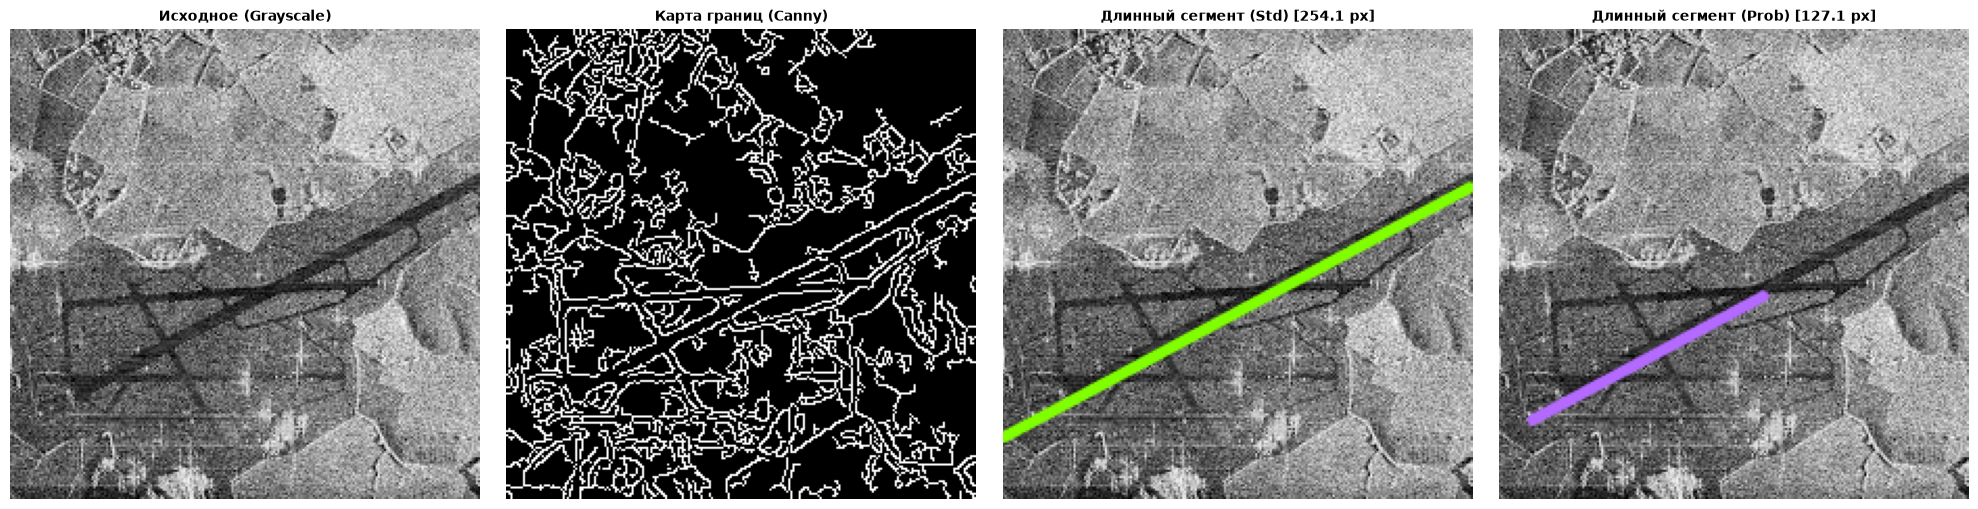

In [39]:
canvas_std = source_bgr.copy()
if best_line_std:
    cv2.line(canvas_std, best_line_std[0], best_line_std[1], (0, 255, 127), 3, cv2.LINE_AA)

canvas_prob = source_bgr.copy()
if best_line_prob is not None:
    p_a = (int(best_line_prob[0]), int(best_line_prob[1]))
    p_b = (int(best_line_prob[2]), int(best_line_prob[3]))
    cv2.line(canvas_prob, p_a, p_b, (255, 105, 180), 3, cv2.LINE_AA)

gray_mask = cv2.cvtColor(gray_map, cv2.COLOR_GRAY2RGB)

hough_visuals = {
    "Исходное (Grayscale)": gray_mask,
    "Карта границ (Canny)": cv2.cvtColor(edge_mask, cv2.COLOR_GRAY2RGB),
    f"Длинный сегмент (Std) [{max_length_std:.1f} px]": cv2.cvtColor(canvas_std, cv2.COLOR_BGR2RGB),
    f"Длинный сегмент (Prob) [{max_length_prob:.1f} px]": cv2.cvtColor(canvas_prob, cv2.COLOR_BGR2RGB),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, display_img) in zip(axes, hough_visuals.items()):
    ax.imshow(display_img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [40]:
print("=== Вывод результатов Хафа ===")
if best_line_std:
    print(f"[Стандартный]: Длина = {max_length_std:.2f} px | Точки = {best_line_std[0]} -> {best_line_std[1]}")
if best_line_prob is not None:
    x_1, y_1, x_2, y_2 = best_line_prob
    print(f"[Вероятностный]: Длина = {max_length_prob:.2f} px | Точки = ({x_1}, {y_1}) -> ({x_2}, {y_2})\n")

=== Вывод результатов Хафа ===
[Стандартный]: Длина = 254.12 px | Точки = (0, 195) -> (224, 75)
[Вероятностный]: Длина = 127.06 px | Точки = (15, 187) -> (127, 127)



In [41]:
# ==============================================================================
# ЧАСТЬ 2. Пороговая фильтрация и выделение дорожного полотна
# ==============================================================================

threshold_results = {}

_, threshold_results["Фиксированный порог (T=90)"] = cv2.threshold(
    gray_map, thresh=90, maxval=255, type=cv2.THRESH_BINARY
)

otsu_val, threshold_results[f"Метод Оцу (T={otsu_val if 'otsu_val' in locals() else 'Auto'})"] = cv2.threshold(
    gray_map, thresh=0, maxval=255, type=cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
threshold_results[f"Метод Оцу (T={int(otsu_val)})"] = threshold_results.pop(list(threshold_results.keys())[-1])

threshold_results["Адаптивный порог (Gauss)"] = cv2.adaptiveThreshold(
    gray_map, maxValue=255, adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY, blockSize=71, C=21
)

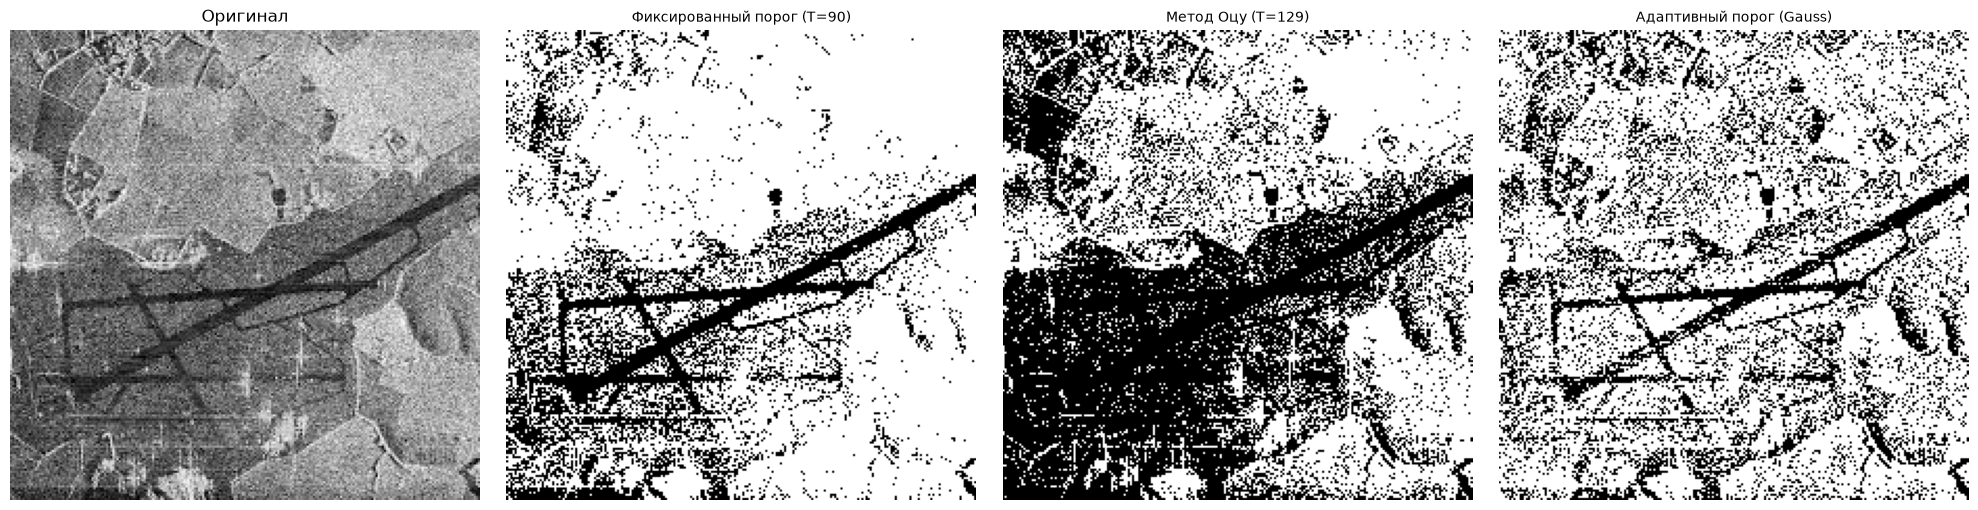

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gray_map, cmap='gray')
axes[0].set_title("Оригинал")
axes[0].axis('off')

for ax, (title, binary_mask) in zip(axes[1:], threshold_results.items()):
    ax.imshow(binary_mask, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

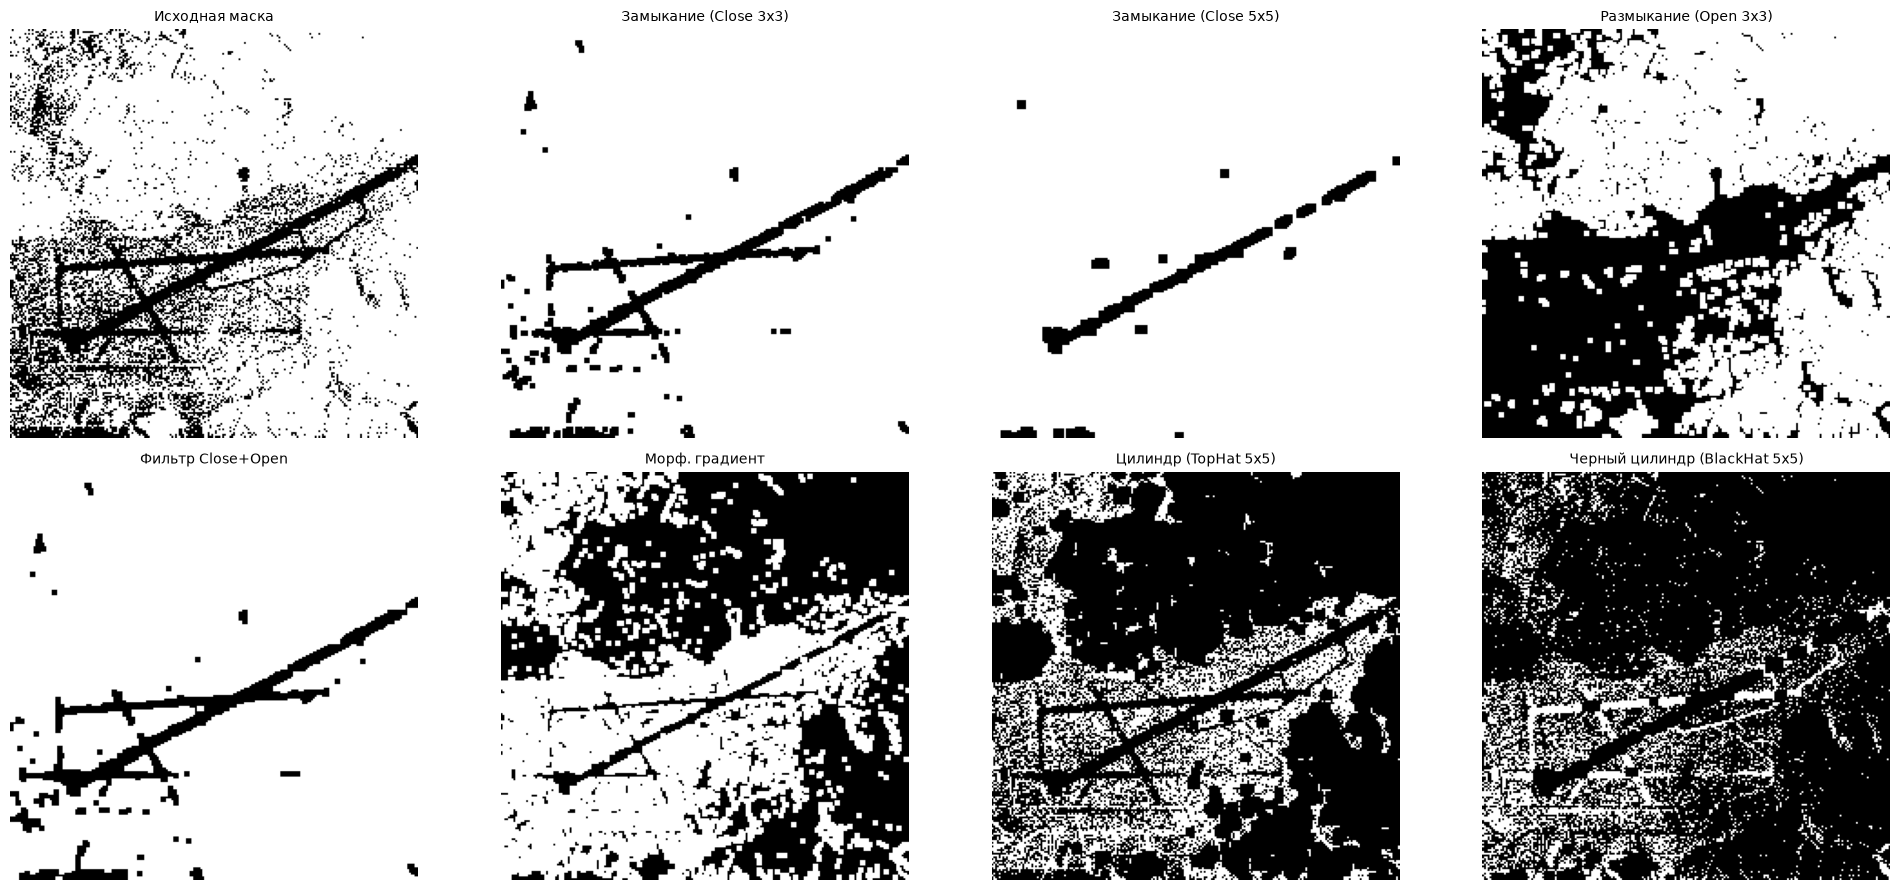

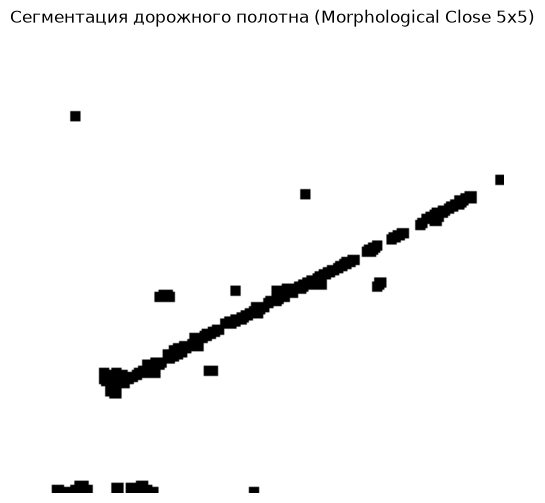

In [43]:
base_binary = threshold_results["Фиксированный порог (T=90)"].copy()

k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
k5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

morphology_tests = {
    "Исходная маска": base_binary,
    "Замыкание (Close 3x3)": cv2.morphologyEx(base_binary, cv2.MORPH_CLOSE, k3),
    "Замыкание (Close 5x5)": cv2.morphologyEx(base_binary, cv2.MORPH_CLOSE, k5),
    "Размыкание (Open 3x3)": cv2.morphologyEx(base_binary, cv2.MORPH_OPEN, k3),
    "Фильтр Close+Open": cv2.morphologyEx(cv2.morphologyEx(base_binary, cv2.MORPH_CLOSE, k3), cv2.MORPH_OPEN, k3),
    "Морф. градиент": cv2.morphologyEx(base_binary, cv2.MORPH_GRADIENT, k3),
    "Цилиндр (TopHat 5x5)": cv2.morphologyEx(base_binary, cv2.MORPH_TOPHAT, k5),
    "Черный цилиндр (BlackHat 5x5)": cv2.morphologyEx(base_binary, cv2.MORPH_BLACKHAT, k5),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (label, morph_img) in zip(axes.flat, morphology_tests.items()):
    ax.imshow(morph_img, cmap='gray')
    ax.set_title(label, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

segmented_road = cv2.morphologyEx(base_binary, cv2.MORPH_CLOSE, k5)

plt.figure(figsize=(8, 6))
plt.imshow(segmented_road, cmap='bone')
plt.title('Сегментация дорожного полотна (Morphological Close 5x5)', fontsize=12)
plt.axis('off')
plt.show()